# Pantheon+SH0ES — Model Comparison
Loads chains produced by `pantheon_inference.ipynb` and compares all cosmological models.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner
import os
from astropy.cosmology import FlatLambdaCDM, LambdaCDM, FlatwCDM, Flatw0waCDM
import astropy.units as u

os.makedirs('plots', exist_ok=True)

# Load data (needed to compute mu_theory at data redshifts)
df   = pd.read_csv('data/Pantheon+SH0ES.dat', sep='\s+', comment='#')
mask = (df['zHD'] > 0.01) & (df['IS_CALIBRATOR'] == 0)
df   = df[mask].reset_index(drop=True)
z    = df['zHD'].values
mB   = df['mB'].values;  x1 = df['x1'].values;  c = df['c'].values
mB_err = df['mBERR'].values; x1_err = df['x1ERR'].values; c_err = df['cERR'].values

# M fixed to SH0ES calibration — breaks H0-M degeneracy
# SNe Ia alone cannot constrain H0 absolutely without an external distance anchor
M_fixed = -19.253

<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_64956/1995032379.py:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df   = pd.read_csv('data/Pantheon+SH0ES.dat', sep='\s+', comment='#')


## 1. Load chains

In [2]:
flat = {
    'Flat ΛCDM'   : np.load('chains/flat_lcdm.npy'),
    'Curved ΛCDM' : np.load('chains/curved_lcdm.npy'),
    'Flat wCDM'   : np.load('chains/flat_wcdm.npy'),
    'Flat w0waCDM': np.load('chains/flat_w0wa.npy'),
}

# Parameter labels per model (cosmological params only — first N columns)
cosmo_labels = {
    'Flat ΛCDM'   : [r'$H_0$', r'$\Omega_m$'],
    'Curved ΛCDM' : [r'$H_0$', r'$\Omega_m$', r'$\Omega_k$'],
    'Flat wCDM'   : [r'$H_0$', r'$\Omega_m$', r'$w$'],
    'Flat w0waCDM': [r'$H_0$', r'$\Omega_m$', r'$w_0$', r'$w_a$'],
}
all_labels = {
    'Flat ΛCDM'   : [r'$H_0$', r'$\Omega_m$', r'$\alpha$', r'$\beta$'],
    'Curved ΛCDM' : [r'$H_0$', r'$\Omega_m$', r'$\Omega_k$', r'$\alpha$', r'$\beta$'],
    'Flat wCDM'   : [r'$H_0$', r'$\Omega_m$', r'$w$', r'$\alpha$', r'$\beta$'],
    'Flat w0waCDM': [r'$H_0$', r'$\Omega_m$', r'$w_0$', r'$w_a$', r'$\alpha$', r'$\beta$'],
}
n_cosmo = {k: len(v) for k, v in cosmo_labels.items()}  # sin cambios

for name, f in flat.items():
    print(f'{name:15s}: {f.shape[0]:6d} samples')

Flat ΛCDM      :  36160 samples
Curved ΛCDM    :  31552 samples
Flat wCDM      :  19264 samples
Flat w0waCDM   :   7552 samples


## 2. Summary table — median and 68% CI for all parameters

In [3]:
for name, f in flat.items():
    lbls = all_labels[name]
    print(f'\n── {name} ──')
    print(f'  {"Param":>8}  {"Median":>9}  {"-σ":>7}  {"+σ":>7}')
    print('  ' + '-'*36)
    for i, lbl in enumerate(lbls):
        p16, p50, p84 = np.percentile(f[:,i], [16, 50, 84])
        print(f'  {lbl:>8}  {p50:>9.4f}  {p50-p16:>7.4f}  {p84-p50:>7.4f}')


── Flat ΛCDM ──
     Param     Median       -σ       +σ
  ------------------------------------
     $H_0$    71.4551   0.1345   0.1359
  $\Omega_m$     0.3433   0.0110   0.0109
  $\alpha$     0.1362   0.0030   0.0029
   $\beta$     3.0933   0.0310   0.0312

── Curved ΛCDM ──
     Param     Median       -σ       +σ
  ------------------------------------
     $H_0$    71.2357   0.1512   0.1535
  $\Omega_m$     0.2210   0.0448   0.0464
  $\Omega_k$     0.2788   0.1040   0.0998
  $\alpha$     0.1354   0.0029   0.0028
   $\beta$     3.0875   0.0306   0.0308

── Flat wCDM ──
     Param     Median       -σ       +σ
  ------------------------------------
     $H_0$    71.2196   0.1462   0.1456
  $\Omega_m$     0.1853   0.0656   0.0629
       $w$    -0.7166   0.0899   0.0760
  $\alpha$     0.1354   0.0029   0.0029
   $\beta$     3.0874   0.0300   0.0305

── Flat w0waCDM ──
     Param     Median       -σ       +σ
  ------------------------------------
     $H_0$    71.1293   0.1822   0.1828
  $

## 3. Hubble diagram — posterior predictive for all models

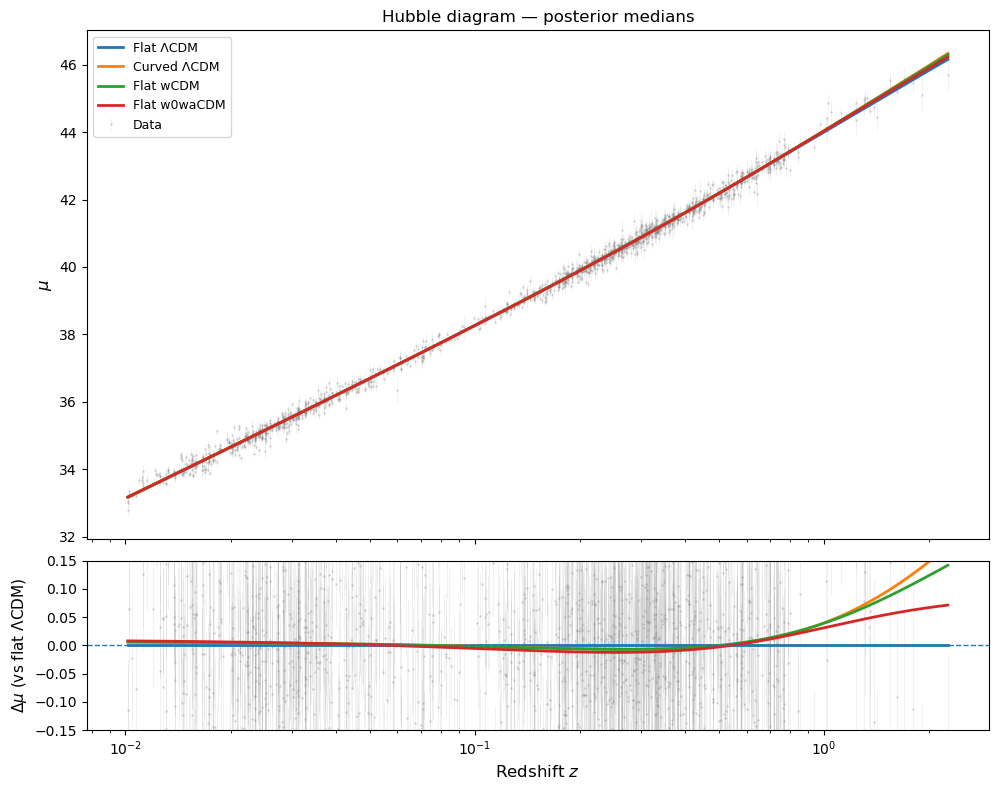

In [6]:
def mu_theory(z, name, theta_cosmo):
    """Compute mu_th given cosmological parameters for each model."""
    H0, Om0 = theta_cosmo[0], theta_cosmo[1]
    if name == 'Flat ΛCDM':
        cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    elif name == 'Curved ΛCDM':
        Ok0 = theta_cosmo[2]
        cosmo = LambdaCDM(H0=H0, Om0=Om0, Ode0=1-Om0-Ok0)
    elif name == 'Flat wCDM':
        cosmo = FlatwCDM(H0=H0, Om0=Om0, w0=theta_cosmo[2])
    elif name == 'Flat w0waCDM':
        cosmo = Flatw0waCDM(H0=H0, Om0=Om0, w0=theta_cosmo[2], wa=theta_cosmo[3])
    return 5*np.log10(cosmo.luminosity_distance(z).to(u.Mpc).value) + 25

COLORS = {'Flat ΛCDM': 'C0', 'Curved ΛCDM': 'C1', 'Flat wCDM': 'C2', 'Flat w0waCDM': 'C3'}
z_th   = np.geomspace(z.min(), z.max(), 400)

# M is fixed — only α and β are in the chain
a_med, b_med = np.median(flat['Flat ΛCDM'][:, 2:], axis=0)
mu_o_plot = mB + a_med*x1 - b_med*c - M_fixed
sig_plot  = np.sqrt(mB_err**2 + (a_med*x1_err)**2 + (b_med*c_err)**2)

# Median theoretical line for each model
fig, axes = plt.subplots(2, 1, figsize=(10, 8),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
ax, ax_res = axes

ax.errorbar(z, mu_o_plot, yerr=sig_plot, fmt='.', color='gray',
            alpha=0.2, ms=2, elinewidth=0.4, capsize=0, label='Data', zorder=1)

# Reference: flat ΛCDM median
med_ref  = np.median(flat['Flat ΛCDM'], axis=0)
mu_ref   = mu_theory(z_th, 'Flat ΛCDM', med_ref)
mu_ref_z = mu_theory(z, 'Flat ΛCDM', med_ref)

for name, f in flat.items():
    nc   = n_cosmo[name]
    med  = np.median(f, axis=0)
    mu_c = mu_theory(z_th, name, med[:nc])
    ax.plot(z_th, mu_c, color=COLORS[name], lw=2, label=name)
    ax_res.plot(z_th, mu_c - mu_ref, color=COLORS[name], lw=2)

ax_res.errorbar(z, mu_o_plot - mu_ref_z, yerr=sig_plot, fmt='.', color='gray',
                alpha=0.2, ms=2, elinewidth=0.4, capsize=0, zorder=1)
ax_res.axhline(0, color='C0', lw=1, ls='--')
ax_res.set_ylabel(r'$\Delta\mu$ (vs flat ΛCDM)', fontsize=11)
ax_res.set_xlabel('Redshift $z$', fontsize=12)
ax_res.set_ylim(-0.15, 0.15)
ax.set_ylabel(r'$\mu$', fontsize=12)
ax.set_title('Hubble diagram — posterior medians', fontsize=12)
ax.legend(fontsize=9); ax.set_xscale('log')
ax_res.set_xscale('log')
plt.tight_layout()
plt.savefig('plots/hubble_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. H₀ and Ωₘ comparison across models

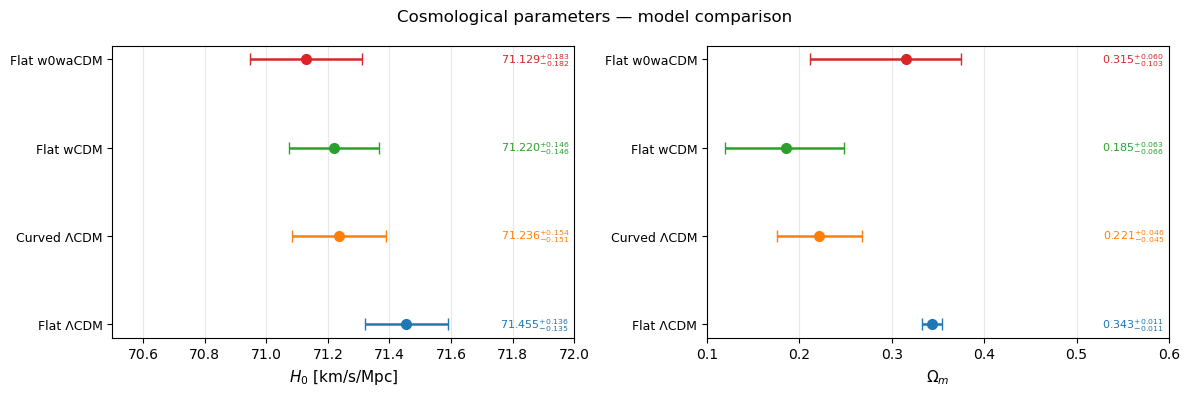

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pidx, plbl, xlo, xhi in [
    (axes[0], 0, r'$H_0$ [km/s/Mpc]', 70.5, 72),
    (axes[1], 1, r'$\Omega_m$',         0.1, 0.6),
]:
    for k, (name, f) in enumerate(flat.items()):
        p16, p50, p84 = np.percentile(f[:, pidx], [16, 50, 84])
        ax.errorbar(p50, k, xerr=[[p50-p16],[p84-p50]],
                    fmt='o', color=COLORS[name], ms=7, capsize=4, lw=1.8)
        ax.text(xhi - 0.01*(xhi-xlo), k, f'{p50:.3f}$^{{+{p84-p50:.3f}}}_{{-{p50-p16:.3f}}}$',
                va='center', ha='right', fontsize=8, color=COLORS[name])
    ax.set_yticks(range(len(flat)))
    ax.set_yticklabels(flat.keys(), fontsize=9)
    ax.set_xlabel(plbl, fontsize=11)
    ax.set_xlim(xlo, xhi)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Cosmological parameters — model comparison', fontsize=12)
plt.tight_layout()
plt.savefig('plots/param_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Overlaid H₀–Ωₘ posteriors

/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_64956/2324206875.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=9)


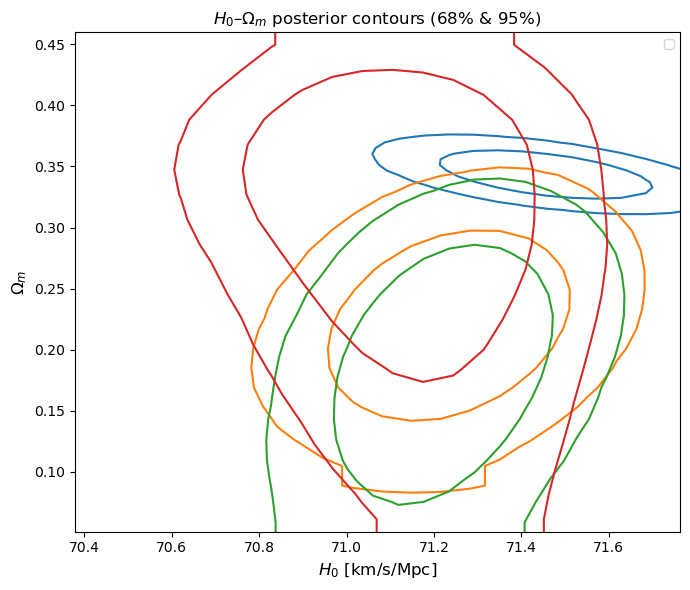

In [10]:
fig = plt.figure(figsize=(7, 6))
for name, f in flat.items():
    # 2D KDE contour using corner internals
    corner.hist2d(f[:,0], f[:,1], levels=[0.68, 0.95],
                  color=COLORS[name], plot_datapoints=False,
                  plot_density=False, fill_contours=False,
                  smooth=1.5, ax=fig.gca(), label=name)
plt.xlabel(r'$H_0$ [km/s/Mpc]', fontsize=12)
plt.ylabel(r'$\Omega_m$', fontsize=12)
plt.legend(fontsize=9)
plt.title(r'$H_0$–$\Omega_m$ posterior contours (68% & 95%)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/H0_Om_contours.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. Dark energy parameters — wCDM and w0waCDM

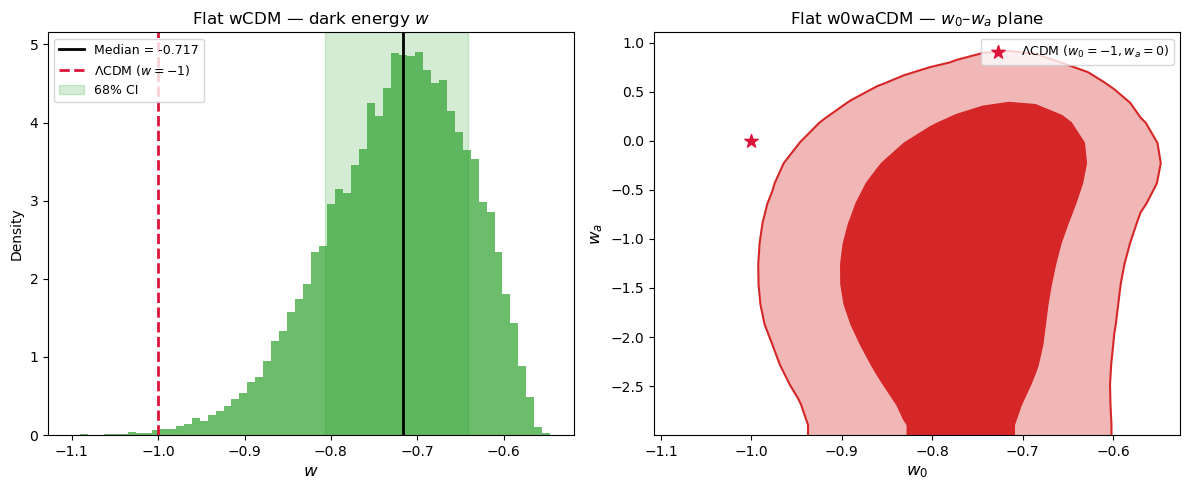

wCDM:    w = -0.717 +0.076 -0.090
w0waCDM: w0 = -0.767 +0.081 -0.090
         wa = -1.131 +0.975 -1.080


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# wCDM: w marginal
w_samples = flat['Flat wCDM'][:, 2]
axes[0].hist(w_samples, bins=60, density=True, color='C2', alpha=0.7)
p16, p50, p84 = np.percentile(w_samples, [16, 50, 84])
axes[0].axvline(p50, color='k', lw=2, label=f'Median = {p50:.3f}')
axes[0].axvline(-1, color='crimson', lw=2, ls='--', label='ΛCDM ($w=-1$)')
axes[0].axvspan(p16, p84, alpha=0.2, color='C2', label='68% CI')
axes[0].set_xlabel(r'$w$', fontsize=12); axes[0].set_ylabel('Density')
axes[0].set_title('Flat wCDM — dark energy $w$'); axes[0].legend(fontsize=9)

# w0waCDM: w0-wa plane
w0_s = flat['Flat w0waCDM'][:, 2]
wa_s = flat['Flat w0waCDM'][:, 3]
corner.hist2d(w0_s, wa_s, levels=[0.68, 0.95], color='C3',
              plot_datapoints=False, plot_density=True,
              fill_contours=True, smooth=1.5, ax=axes[1])
axes[1].scatter(-1, 0, color='crimson', s=100, zorder=5,
                label='ΛCDM ($w_0=-1, w_a=0$)', marker='*')
axes[1].set_xlabel(r'$w_0$', fontsize=12); axes[1].set_ylabel(r'$w_a$', fontsize=12)
axes[1].set_title('Flat w0waCDM — $w_0$–$w_a$ plane'); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plots/dark_energy.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'wCDM:    w = {p50:.3f} +{p84-p50:.3f} -{p50-p16:.3f}')
w0_p = np.percentile(w0_s,[16,50,84]); wa_p = np.percentile(wa_s,[16,50,84])
print(f'w0waCDM: w0 = {w0_p[1]:.3f} +{w0_p[2]-w0_p[1]:.3f} -{w0_p[1]-w0_p[0]:.3f}')
print(f'         wa = {wa_p[1]:.3f} +{wa_p[2]-wa_p[1]:.3f} -{wa_p[1]-wa_p[0]:.3f}')